In [41]:
#Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_Belgium = df[(df['job_country'] == 'Belgium')].dropna(subset=['salary_year_avg'])

In [43]:
job_titles = df_Belgium['job_title_short'].value_counts().index[:6].tolist()

print(type(job_titles))
job_titles

<class 'list'>


['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [44]:
(df_Belgium['job_title_short'] == 'Senior Data Analyst').value_counts()

job_title_short
False    14853
True       913
Name: count, dtype: int64

In [45]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist', 'Senior Data Analyst', 'Senior Data Engineer', 'Senior Data Scientist']
job_titles

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Senior Data Analyst',
 'Senior Data Engineer',
 'Senior Data Scientist']

In [46]:
df_Belgium_top6 = df_Belgium[ df_Belgium['job_title_short'].isin(job_titles) ]



In [47]:
job_order = df_Belgium_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index 
print(type(job_order))
job_order


<class 'pandas.Index'>


Index(['Senior Data Scientist', 'Senior Data Engineer', 'Data Scientist',
       'Data Engineer', 'Senior Data Analyst', 'Data Analyst'],
      dtype='str', name='job_title_short')

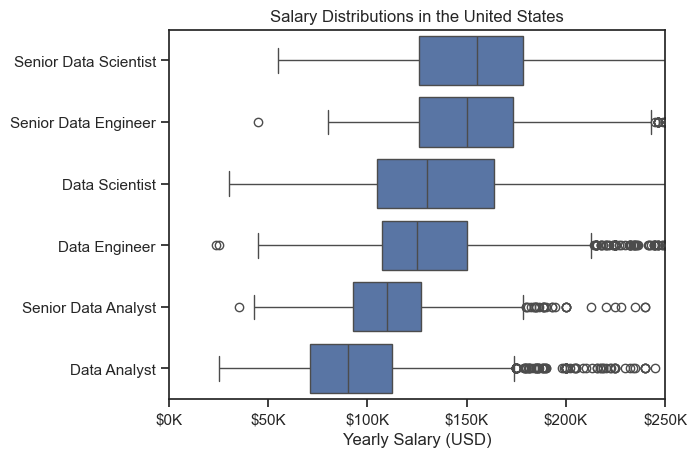

In [ ]:
sns.boxplot(data=df_Belgium_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')
plt.title('Salary Distributions in Belgium')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0,250_000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

In [50]:
df_DA_Belgium = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == "Belgium")].copy()

df_DA_Belgium = df_DA_Belgium.dropna(subset=['salary_year_avg'])

In [52]:
df_DA_Belgium = df_DA_Belgium.explode('job_skills')

df_DA_Belgium[['salary_year_avg', 'job_skills']].head()

,salary_year_avg,job_skills
26818,54988.0,express
26818,54988.0,power bi
26818,54988.0,excel
26818,54988.0,sheets
26818,54988.0,sap


In [57]:
df_DA_top_pay = df_DA_Belgium.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay

,count,median
job_skills,,
aws,5,165000.0
bigquery,1,165000.0
gcp,3,165000.0
java,1,165000.0
snowflake,1,165000.0
spark,2,165000.0
scala,1,165000.0
nosql,4,165000.0
flow,4,164391.0


In [62]:
df_DA_skills = df_DA_Belgium.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
nosql,4,165000.00
aws,5,165000.00
flow,4,164391.00
azure,8,164391.00
databricks,3,111175.00
sql,7,111175.00
power bi,4,84337.50
powerpoint,3,80850.00
excel,6,77958.75


In [61]:
len(df_DA_Belgium['job_title_short'])


85

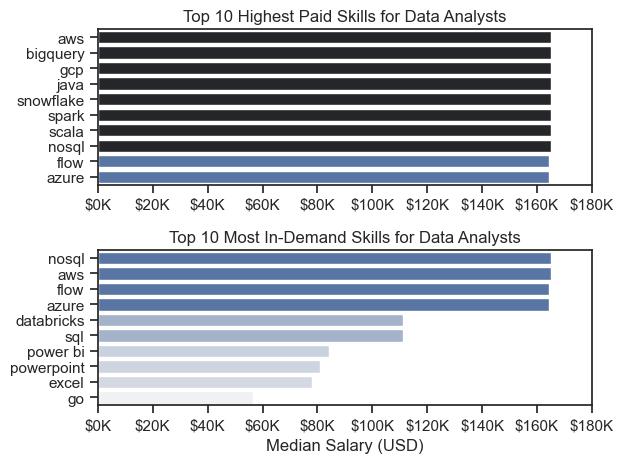

In [63]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')
ax[0].set_xlim(0,180000)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].legend().set_visible(False)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue= 'median', palette='light:b')
ax[1].set_xlim(0,180000)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].legend().set_visible(False)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()